# Notebook 17 — Inference Speed Benchmark

**The question:** Once a decoder is trained, how fast is it?

For a real quantum computer, the decoder must keep pace with the syndrome  
generation rate — currently ~1 MHz (1 syndrome round per microsecond on IBM hardware).  
A decoder that achieves 0.1% LER but takes 1 ms per shot is useless in practice.

**What we measure:**
- Throughput: shots decoded per second (higher = better)
- Latency: time per single shot (lower = better, relevant for real-time decoding)
- GPU vs CPU throughput for batch decoding
- Comparison: all NN decoders + MWPM

**Key metric for real hardware:**  
`shots/second > syndrome_rate × distance²`  
For d=5 at 1 MHz: need > 25 × 10⁶ shots/second for real-time decoding.

**Prerequisite:** Run notebooks 14 and 15 first.
```bash
pip install stim pymatching torch numpy matplotlib
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import stim
import pymatching
import pickle
import time
import os, warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


---
## 1. Load Models and Data

In [2]:
def load_circuit_from_pickle(pkl_path: str):
    """Load a stim.Circuit from pickle — bypasses stim version mismatch."""
    with open(pkl_path, "rb") as f:
        raw = f.read()
    start   = raw.find(b"QUBIT_COORDS")
    obs_pos = raw.rfind(b"OBSERVABLE_INCLUDE")
    if start == -1 or obs_pos == -1:
        raise ValueError(f"Not a valid stim circuit pickle: {pkl_path}")
    end = obs_pos
    while end < len(raw):
        b = raw[end]
        if b == 0x0A: end += 1; break
        elif b > 0x7E or (b < 0x20 and b not in (0x09, 0x0D)): break
        end += 1
    return stim.Circuit(raw[start:end].decode("ascii"))

# ── Model definitions (minimal, for loading only) ─────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim=240, hidden=[512,256,128], dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i<len(hidden)-1 else 0.0)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class LSTMDecoder(nn.Module):
    def __init__(self, input_size=24, lstm_hidden=64, lstm_layers=2,
                 dense=[96,48,24], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d,h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d,1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

class SyndromeTransformer(nn.Module):
    def __init__(self, input_size=24, num_steps=11, d_model=64, nhead=4,
                 num_layers=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_embed  = nn.Embedding(num_steps, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model,32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32,1))
    def forward(self, x):
        tok = self.input_proj(x)
        pos = torch.arange(x.shape[1], device=x.device)
        tok = tok + self.pos_embed(pos).unsqueeze(0)
        return self.head(self.transformer(tok).mean(dim=1)).squeeze(-1)

# Load
def load_model(cls, path, *args):
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m  = cls(*args).to(DEVICE).eval()
    m.load_state_dict(ck['model_state'])
    return m, ck['test_ler']

mlp,         ler_mlp  = load_model(MLP,                "models/heavyhex/mlp.pt",         240)
lstm_det,    ler_lstm = load_model(LSTMDecoder,         "models/heavyhex/lstm_det.pt",    24)
lstm_raw,    ler_lraw = load_model(lambda s: LSTMDecoder(s), "models/heavyhex/lstm_raw.pt", 40)
transformer, ler_tr   = load_model(SyndromeTransformer, "models/heavyhex/transformer.pt", 24, 11)

# Load test data
det_flat = np.load("data/heavyhex/detection_events.npy").astype(np.float32)[:20_000]
det_temp = np.load("data/heavyhex/det_temporal.npy").astype(np.float32)[:20_000]
raw_temp = np.load("data/heavyhex/raw_measurements.npy").astype(np.float32)[:20_000]

# Reshape raw to temporal
N = raw_temp.shape[0]
raw_t = np.zeros((N, 11, 40), dtype=np.float32)
raw_t[:, :10, :] = raw_temp[:, :400].reshape(N, 10, 40)
raw_t[:, 10, :25] = raw_temp[:, 400:425]

circuit = load_circuit_from_pickle("s_stim_circ_z.pickle")

dem = circuit.detector_error_model(
    decompose_errors=True, approximate_disjoint_errors=True)
mwpm_matching = pymatching.Matching.from_detector_error_model(dem)

print("All models and data loaded.")

All models and data loaded.


---
## 2. Benchmark Function

In [3]:
def benchmark_nn(model, X, batch_size, n_warmup=3, n_repeat=10):
    """
    Benchmark NN decoder throughput.
    Returns: (shots_per_second, latency_per_shot_ms)
    """
    model.eval()
    X_tensor = torch.tensor(X).to(DEVICE)

    # Warmup — fills CUDA kernels cache
    with torch.no_grad():
        for _ in range(n_warmup):
            for i in range(0, len(X_tensor), batch_size):
                _ = torch.sigmoid(model(X_tensor[i:i+batch_size]))

    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()

    # Timed run
    times = []
    with torch.no_grad():
        for _ in range(n_repeat):
            t0 = time.perf_counter()
            for i in range(0, len(X_tensor), batch_size):
                _ = torch.sigmoid(model(X_tensor[i:i+batch_size]))
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)

    total_shots   = len(X)
    mean_time     = np.mean(times)
    shots_per_sec = total_shots / mean_time
    latency_ms    = mean_time / total_shots * 1000
    return shots_per_sec, latency_ms


def benchmark_mwpm(det_events, matching, n_repeat=5):
    """Benchmark MWPM throughput."""
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        _ = matching.decode_batch(det_events.astype(np.bool_))
        times.append(time.perf_counter() - t0)
    mean_time     = np.mean(times)
    shots_per_sec = len(det_events) / mean_time
    latency_ms    = mean_time / len(det_events) * 1000
    return shots_per_sec, latency_ms


print("Benchmark functions defined.")

Benchmark functions defined.


---
## 3. Run Benchmarks at Multiple Batch Sizes

In [4]:
BATCH_SIZES  = [1, 16, 64, 256, 1024, 4096]
N_BENCHMARK  = min(10_000, len(det_flat))

results = {}   # decoder_name → {batch_size → (shots/sec, latency_ms)}

decoders = [
    ("MLP (240 flat)",     mlp,         det_flat[:N_BENCHMARK]),
    ("LSTM-det (11×24)",   lstm_det,    det_temp[:N_BENCHMARK]),
    ("LSTM-raw (11×40)",   lstm_raw,    raw_t[:N_BENCHMARK]),
    ("Transformer (11×24)",transformer, det_temp[:N_BENCHMARK]),
]

print(f"Benchmarking on {N_BENCHMARK:,} shots...")
print(f"Device: {DEVICE}")
print()

for name, model, X in decoders:
    results[name] = {}
    print(f"  {name}:")
    for bs in BATCH_SIZES:
        sps, lat = benchmark_nn(model, X, bs)
        results[name][bs] = (sps, lat)
        print(f"    batch={bs:5d}:  {sps:>12,.0f} shots/s  "
              f"({lat*1000:.3f} µs/shot)")
    print()

# MWPM (CPU only, not batched by GPU)
print("  MWPM (PyMatching, CPU):")
mwpm_sps, mwpm_lat = benchmark_mwpm(det_flat[:N_BENCHMARK], mwpm_matching)
results["MWPM"] = {"batch_all": (mwpm_sps, mwpm_lat)}
print(f"    batch=all:  {mwpm_sps:>12,.0f} shots/s  ({mwpm_lat*1000:.3f} µs/shot)")

Benchmarking on 10,000 shots...
Device: cuda

  MLP (240 flat):
    batch=    1:         1,396 shots/s  (716.589 µs/shot)
    batch=   16:        20,247 shots/s  (49.390 µs/shot)
    batch=   64:        77,272 shots/s  (12.941 µs/shot)
    batch=  256:       314,106 shots/s  (3.184 µs/shot)
    batch= 1024:     1,712,821 shots/s  (0.584 µs/shot)
    batch= 4096:     2,802,369 shots/s  (0.357 µs/shot)

  LSTM-det (11×24):
    batch=    1:         1,324 shots/s  (755.044 µs/shot)
    batch=   16:        19,972 shots/s  (50.070 µs/shot)
    batch=   64:        77,899 shots/s  (12.837 µs/shot)
    batch=  256:       236,878 shots/s  (4.222 µs/shot)
    batch= 1024:       298,712 shots/s  (3.348 µs/shot)
    batch= 4096:       327,792 shots/s  (3.051 µs/shot)

  LSTM-raw (11×40):
    batch=    1:         1,333 shots/s  (750.176 µs/shot)
    batch=   16:        19,828 shots/s  (50.433 µs/shot)
    batch=   64:        75,918 shots/s  (13.172 µs/shot)
    batch=  256:       238,263 shots/s  (4

---
## 4. Speed vs Accuracy Plot

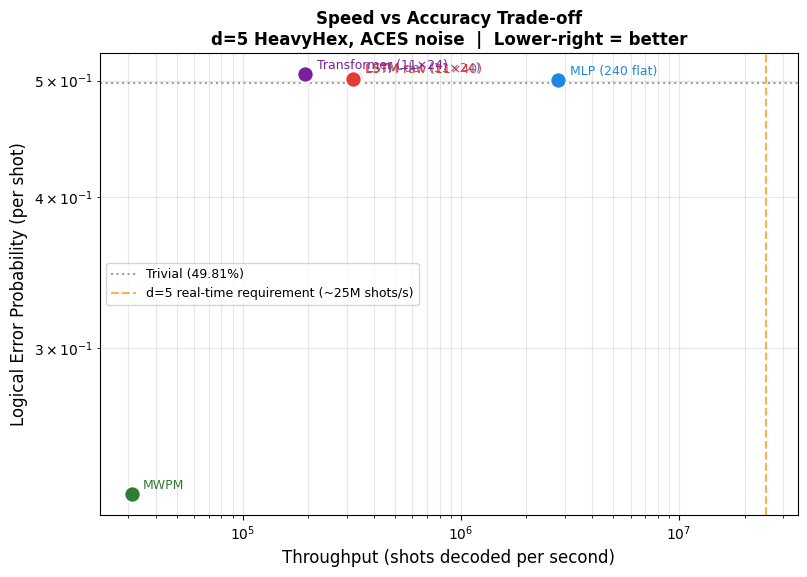

Saved → figures/17_speed_vs_accuracy.png


In [5]:
# Best throughput for each decoder (largest batch size for NN)
best_bs   = BATCH_SIZES[-1]
summary   = []

for name, model, X in decoders:
    ler_map = {
        "MLP (240 flat)":      ler_mlp,
        "LSTM-det (11×24)":    ler_lstm,
        "LSTM-raw (11×40)":    ler_lraw,
        "Transformer (11×24)": ler_tr,
    }
    sps, _  = results[name][best_bs]
    summary.append((name, sps, ler_map[name]))

mwpm_results_load = np.load("results/heavyhex/mwpm_result.npy")
summary.append(("MWPM", mwpm_sps, float(mwpm_results_load[0])))

colors_map = {
    "MLP (240 flat)":       '#1E88E5',
    "LSTM-det (11×24)":     '#5C6BC0',
    "LSTM-raw (11×40)":     '#E53935',
    "Transformer (11×24)":  '#7B1FA2',
    "MWPM":                 '#2E7D32',
}

fig, ax = plt.subplots(figsize=(9, 6))

for name, sps, ler in summary:
    ax.scatter(sps, ler, s=140, color=colors_map.get(name, '#888888'),
               zorder=5, edgecolors='white', lw=1.5)
    ax.annotate(name, (sps, ler),
                textcoords='offset points', xytext=(8, 4),
                fontsize=9, color=colors_map.get(name, '#888888'))

trivial = float(mwpm_results_load[1])
ax.axhline(y=trivial, color='#9E9E9E', lw=1.5, ls=':', label=f'Trivial ({100*trivial:.2f}%)')

# Real-time requirement line (illustrative)
# d=5 at 1 MHz syndrome rate: need > 25M shots/s
ax.axvline(x=25e6, color='#FF8F00', lw=1.5, ls='--', alpha=0.7,
           label='d=5 real-time requirement (~25M shots/s)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(which='both', alpha=0.3)
ax.set_xlabel('Throughput (shots decoded per second)', fontsize=12)
ax.set_ylabel('Logical Error Probability (per shot)', fontsize=12)
ax.set_title('Speed vs Accuracy Trade-off\n'
             'd=5 HeavyHex, ACES noise  |  Lower-right = better', fontweight='bold')
ax.legend(fontsize=9)

os.makedirs("figures", exist_ok=True)
fig.savefig('figures/17_speed_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/17_speed_vs_accuracy.png")

---
## 5. Throughput vs Batch Size Plot

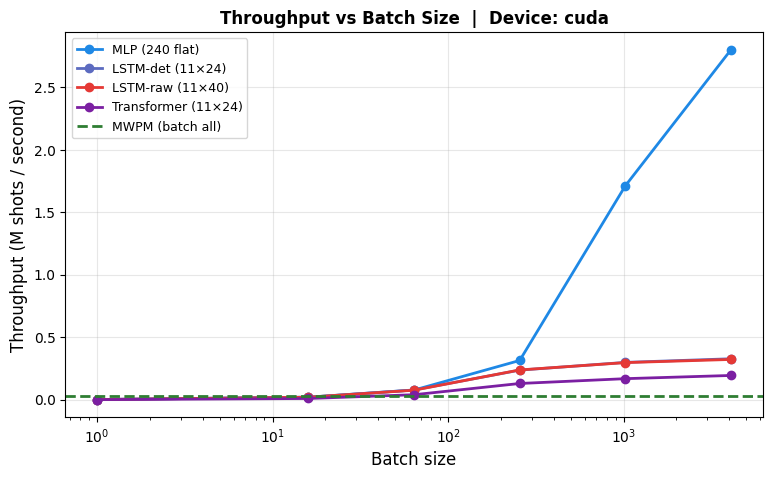

Saved → figures/17_throughput_vs_batchsize.png

Peak throughput summary  (batch size = 4096)
  Decoder                            Shots/sec     µs/shot       LER
  ----------------------------------------------------------------
  MLP (240 flat)                     2,802,369      0.357  50.0333%
  LSTM-det (11×24)                     327,792      3.051  50.2667%
  LSTM-raw (11×40)                     322,251      3.103  50.1867%
  Transformer (11×24)                  194,121      5.151  50.6200%
  MWPM                                  31,088     32.167  22.6930%


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

for name, model, X in decoders:
    bs_list  = BATCH_SIZES
    sps_list = [results[name][bs][0] for bs in bs_list]
    ax.semilogx(bs_list, [s/1e6 for s in sps_list],
                'o-', color=colors_map.get(name, '#888888'), lw=2, ms=6,
                label=name)

ax.axhline(y=mwpm_sps/1e6, color=colors_map['MWPM'], lw=2, ls='--',
           label='MWPM (batch all)')

ax.set_xlabel('Batch size', fontsize=12)
ax.set_ylabel('Throughput (M shots / second)', fontsize=12)
ax.set_title(f'Throughput vs Batch Size  |  Device: {DEVICE}', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.savefig('figures/17_throughput_vs_batchsize.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/17_throughput_vs_batchsize.png")

# Print summary table
print()
print("=" * 65)
print(f"Peak throughput summary  (batch size = {best_bs})")
print("=" * 65)
print(f"  {'Decoder':<28}  {'Shots/sec':>14}  {'µs/shot':>10}  {'LER':>8}")
print("  " + "-"*64)
for name, sps, ler in summary:
    lat_us = 1e6 / sps
    print(f"  {name:<28}  {sps:>14,.0f}  {lat_us:>9.3f}  {100*ler:>7.4f}%")